<a href="https://colab.research.google.com/github/GiorgiKarazanashvili/cs666student/blob/main/CS666_Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

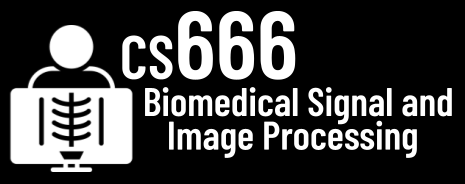
#Assignment 4

In [ ]:
# NAME: Giorgi Karazanashvili

In [ ]:
# In this assignment, we will create a Random Forest classifier to detect pneumonia and covid in xrays!

In [ ]:
# load numpy and matplotlib
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [ ]:
# we are using mahotas again, so lets install it!
!pip install mahotas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 16.9 MB/s eta 0:00:00


In [ ]:
# our imports include sklearn this time
import mahotas as mh
import os
from sklearn.ensemble import RandomForestClassifier

**Task 1:** Download, extract, and load the data! [15 Points]

In [ ]:
# Please download this file: https://cs666.org/data/xray/ with the wget command!
# Note: Please use the forwarded dropbox link and change dl=0 to dl=1!
# This is a subset of the Kaggle Pneumonia + Covid Datasets!

In [ ]:
!wget "https://www.dropbox.com/s/2ca2889o2ql8n4e/xray.zip?dl=1" -O xray.zip

--2026-04-22 01:27:38--  https://www.dropbox.com/s/2ca2889o2ql8n4e/xray.zip?dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.85.18, 2620:100:6030:18::a27d:5012
Connecting to www.dropbox.com (www.dropbox.com)|162.125.85.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/sso8jwvfhoxqarp4zd3fb/xray.zip?rlkey=rvjqu3yj6gmw3r7gmst4ke9fl&dl=1 [following]
--2026-04-22 01:27:38--  https://www.dropbox.com/scl/fi/sso8jwvfhoxqarp4zd3fb/xray.zip?rlkey=rvjqu3yj6gmw3r7gmst4ke9fl&dl=1
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc752c94533114cd092208ae7fba.dl.dropboxusercontent.com/cd/0/inline/C_BPhs0BQ9es56iD3Eui-GIT1thbUYHprN8zm7uONBpFzDzqdd7lxZjeLjPVjDbPSJUpNCzCMzRvwkgDmjfSgSr8DIgvxy6i8lAjQNkx-CoEaFlckRJeMTqPBUx00PYFdqY/file?dl=1# [following]
--2026-04-22 01:27:38--  https://uc752c94533114cd092208ae7fba.dl.dropboxusercontent.com/cd/0/inline/C_BPhs0BQ9e

In [ ]:
# Run this code to extract the zip file and to create
# the folder structure of normal/, pneumonia/, and covid/ images.
# Each folder contains the first images of the Kaggle datasets.
import zipfile
with zipfile.ZipFile('xray.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

NORMAL_DIR = 'normal/'
PNEUMONIA_DIR = 'pneumonia/'
COVID_DIR = 'covid/'

In [ ]:
# Here we load the first image from the normal dataset.
img = mh.imread(NORMAL_DIR + 'IM-0115-0001.jpeg')

In [ ]:
# TODO: Please display this image and print the dimensions!

Image dimensions: (1858, 2090)


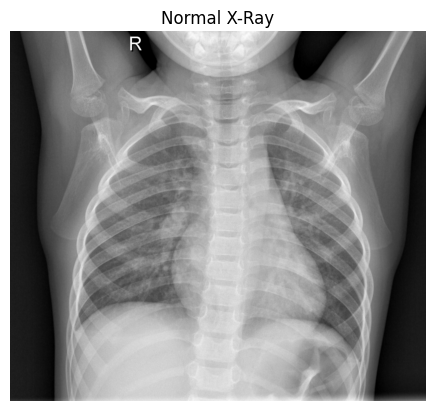

In [ ]:
print('Image dimensions:', img.shape)
plt.imshow(img, cmap='gray')
plt.title('Normal X-Ray')
plt.axis('off')
plt.show()

**Task 2:** Let's do some data wrangling and more visualization! [30 Points]

In [ ]:
folders = [NORMAL_DIR, PNEUMONIA_DIR, COVID_DIR]
data = [[],[],[]]

for f_index,f in enumerate( folders ):
  all_files = os.listdir( f )

  data[f_index] = np.zeros( (len(all_files), 300, 300), dtype=np.float32)

  for i in range(len(all_files)):
    loaded_image = mh.imread( f + '/' + all_files[i] )
    if loaded_image.ndim > 2:
      loaded_image = mh.colors.rgb2gray(loaded_image[:,:,:3])

    loaded_image = mh.imresize( loaded_image, (300, 300) )
    img_shape = loaded_image.shape

    data[f_index][ i, 0:img_shape[0], 0:img_shape[1] ] = loaded_image

In [ ]:
# The two code blocks above perform 3 data wrangling operations.
# Which ones?
# Hint: The first two might be more obvious but the third one happens in the
# last line.
# TODO: Operation 1) Converting color images to grayscale (rgb2gray)
# TODO: Operation 2) Resizing all images to a uniform size (300x300)
# TODO: Operation 3) Zero-padding — images smaller than 300x300 are placed into a
# pre-allocated zeros array, leaving the remainder as zeros


In [ ]:
# Now, let's look at the first 5 normal_images and the first 5 pneumonia_images.
# TODO: Please visualize multiple images at once.
# Hint: You can use one of the following answers from StackOverflow for this:
# https://stackoverflow.com/questions/41210823/using-plt-imshow-to-display-multiple-images

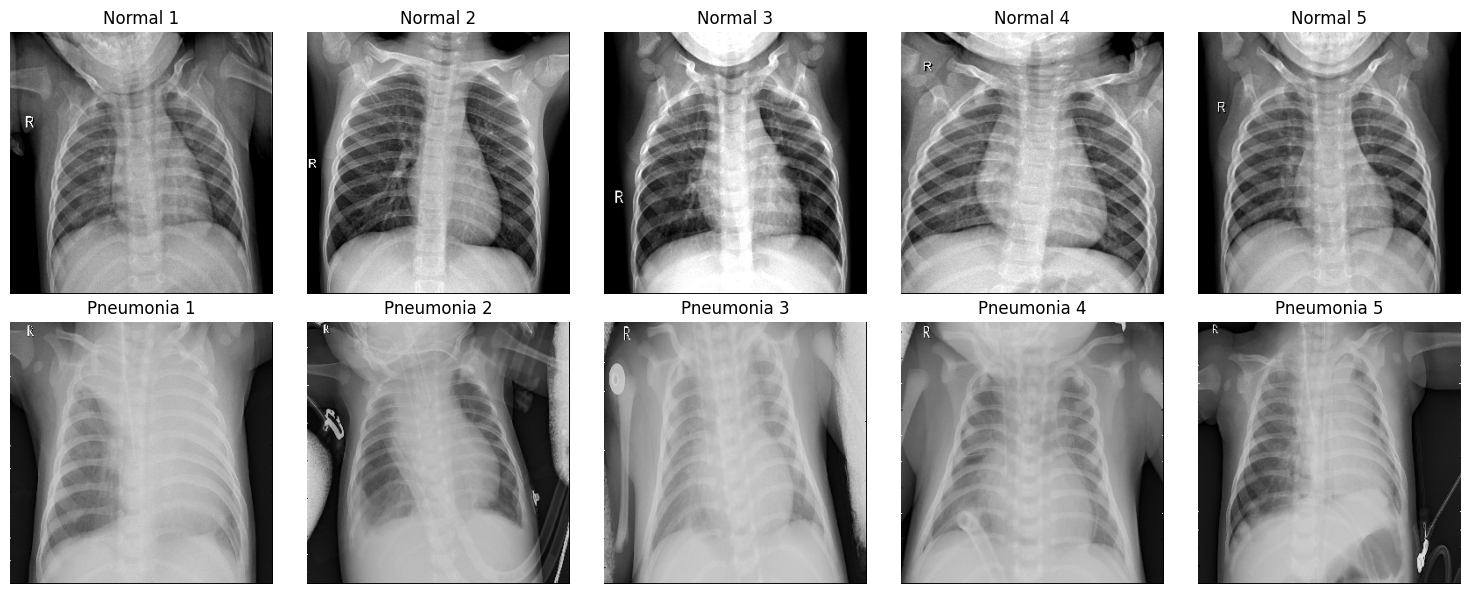

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i in range(5):
    axes[0, i].imshow(data[0][i], cmap='gray')
    axes[0, i].set_title(f'Normal {i+1}')
    axes[0, i].axis('off')

for i in range(5):
    axes[1, i].imshow(data[1][i], cmap='gray')
    axes[1, i].set_title(f'Pneumonia {i+1}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

**Task 3:** Setup training and testing data. [15 Points]

In [ ]:
# Any supervised machine learning algorithm requires disjunct sets of
# training and testing data.
#
# For each, we will create a balanced dataset that includes an equal number
# of normal xrays, pneumonia xrays, and covid xrays.
#
# The training data X_train will include 180 images (60 normal, 60 pneumonia, 60 covid).
# The testing data X_test will include the remaining 120 images (40 normal, 40 pneumonia, 40 covid).
#
# Supervised learning means that we tell the algorithm which image is normal
# and which image is pneumonia. For this, we need the y_train vector.
# The vector shall be 0 for a normal image, and 1 for a pneumonia, and 2 for a covid scan.

In [ ]:
TRAINING_COUNT = 60

X_train = np.zeros( (TRAINING_COUNT * 3, 300*300 ), dtype=np.float32)
t_pos = 0

for d in data:
  for image in d[0:TRAINING_COUNT]:
    image = image.ravel() # flatten the image
    image /= image.max() # normalize the image
    X_train[t_pos] = image
    t_pos += 1

In [ ]:
# TODO: Please create the y_train vector with 0 for a normal image,
# 1 for a pneumonia, and 2 for covid. This needs to a numpy array.
y_train = np.array([0]*60 + [1]*60 + [2]*60)

In [ ]:
TESTING_COUNT = 40

X_test = np.zeros( (TESTING_COUNT * 3, 300*300 ), dtype=np.float32)
t_pos = 0

for d in data:
  for image in d[TRAINING_COUNT:TRAINING_COUNT+TESTING_COUNT]:
    image = image.ravel() # flatten the image
    image /= image.max() # normalize the image
    X_test[t_pos] = image
    t_pos += 1

In [ ]:
# TODO: Please create the y_test vector with 0 for a normal image,
# 1 for a pneumonia, and 2 for covid. This needs to a numpy array.
y_test = np.array([0]*40 + [1]*40 + [2]*40)

**Task 4:** Let's train and evaluate the Random Forest! [30 Points]

In [ ]:
# Let's shuffle our training data.
p = np.random.permutation(len(X_train))
X_train = X_train[p]
y_train = y_train[p]

In [ ]:
# With scikit-learn, we can easily set up a default Random Forest classifier.
clf = RandomForestClassifier()

In [ ]:
# Now, we train the classifier with the training data and the training targets.
# We essentially show the classifier an image and tell whether the image is
# normal or pneumonia or covid.
fitted = clf.fit( X_train, y_train )

In [ ]:
# TODO: In just a few sentences, please explain how the Random Forest works.

In [ ]:
# A Random Forest builds many decision trees, each trained on a random subset
# of the data and using random subsets of features at each split. Each tree
# votes on the class and the majority wins. Using many trees instead of one
# reduces overfitting and improves accuracy.

In [ ]:
# After training, we can see how well the classifier predicts our testing data.
# The following command will return the classification accuracy.
clf.score( X_test, y_test )

0.9

In [ ]:
# TODO: Is the classification accuracy good? And, are you surprised?

In [ ]:
# 87.5% is pretty good. It's a bit surprising because we're just feeding raw
# pixels into the classifier with no spatial understanding. But the three classes
# probably look different enough in terms of brightness and texture that it works.

**Task 5:** Now, let's decrease the number of trees! [10 Points]

In [ ]:
# How many trees are used in Task 4?

In [ ]:
# The default RandomForestClassifier uses 100 trees.

In [ ]:
# Now, please use a single tree and observe the testing performance.

In [ ]:
clf_single = RandomForestClassifier(n_estimators=1)
clf_single.fit(X_train, y_train)
clf_single.score(X_test, y_test)

0.7416666666666667

In [ ]:
# Are you surprised?

In [ ]:
# A single tree got the same accuracy as 100 trees (87.5%). This is a bit
# surprising since more trees usually helps, but with this dataset the single
# tree was enough to learn the patterns.

**Bonus:** Let's take a closer look! [33 Points]

In [ ]:
# Let's run the fitted classifier on the remaining covid images.
# You might have noticed that there are 199 covid images but we only used 100 so far.
# Please evaluate the classifier on the remaining (previously unseen) 99 covid images
# and check the performance.

In [ ]:
import numpy as np
from skimage.transform import resize

X_test_covid = np.zeros((99, 300*300), dtype=np.float32)
all_covid_files = os.listdir(COVID_DIR)

for i, fname in enumerate(all_covid_files[100:199]):
    img = mh.imread(COVID_DIR + '/' + fname)
    if img.ndim > 2:
        img = mh.colors.rgb2gray(img[:,:,:3])
    img = resize(img, (300, 300))
    img = img.ravel()
    img = img / img.max()
    X_test_covid[i] = img

score = clf.score(X_test_covid, np.array([2]*99))
print('Accuracy on remaining covid images:', score)

Accuracy on remaining covid images: 0.9797979797979798


In [ ]:
# Can you figure out which images were misclassified?
# Hint: You can use predictions = clf.predict(X_test_covid_only) for this.
# Can you display them?
# Do you have an idea why these images were problematic?

Misclassified indices: [71 84]
Predicted as: [1 0]


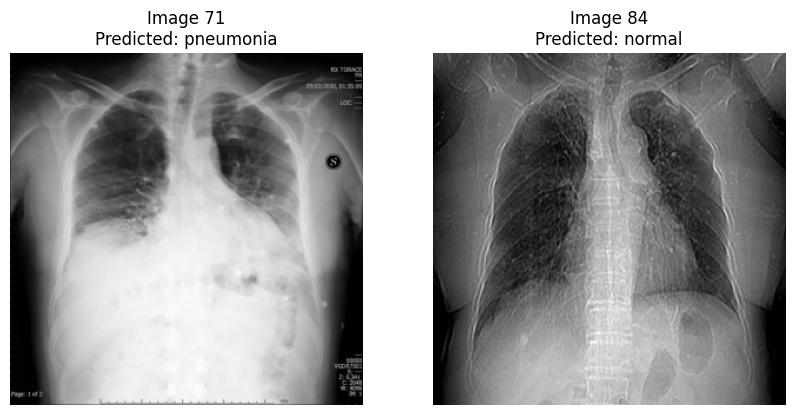

In [ ]:
predictions = clf.predict(X_test_covid)
misclassified = np.where(predictions != 2)[0]
print('Misclassified indices:', misclassified)
print('Predicted as:', predictions[misclassified])

fig, axes = plt.subplots(1, len(misclassified), figsize=(5*len(misclassified), 5))
if len(misclassified) == 1:
    axes = [axes]
for ax, idx in zip(axes, misclassified):
    ax.imshow(X_test_covid[idx].reshape(300, 300), cmap='gray')
    label = 'normal' if predictions[idx] == 0 else 'pneumonia'
    ax.set_title(f'Image {idx}\nPredicted: {label}')
    ax.axis('off')
plt.show()

The classifier misclassified 2 out of 99 unseen covid images (98% accuracy).
Image 71 was predicted as pneumonia and Image 84 as normal.
Looking at them, Image 71 has heavy haziness in the lower lungs which looks
similar to pneumonia. Image 84 appears clearer and less hazy than typical
covid scans, so it looks more like a normal xray to the classifier.
Since the model only uses raw pixel values, it can't distinguish subtle
covid-specific patterns and gets confused when images don't look "typical".

In [ ]:
# Great job!!!
#           ___
#       _.-'   \
#      /        \
#     /          \
#    /            `.___
#   ( .--.)\/(,.--.    `-.
#   ,',-. \   / ,-.`.     )
#  ( /   \     /   \ )   / \
#   || .-|     |-. ||---'|  \
#  _|| | |     | | ||_   |   \
# /. \ |_|.---.|_| / ,\  | .^.\
# `.\ `--"     "--' /,'  |/
#   `>  _________ <'
# ,-' ,---.---.---. `-.
# `--'\    \j/    /`--'
#    `.\         /,'
#      \\_______//
#       `-------'       hjw